(mmm_endogenous_budget)=
# Endogenous Budgets: Separating Designed from Chosen Spend

An MMM regresses sales on spend, but the causal meaning of that regression depends on how spend was assigned. Marketing teams rarely set budgets at random. They spend more when they expect a busy season, when a planner's forecast looks strong, or when a competitor goes quiet. If that expectation carries information about demand the model cannot see, spend and the sales error share a cause, and the MMM credits each channel with the demand its budget followed.

Lift tests are the usual remedy, and PyMC-Marketing adds them to the model as an extra likelihood term (see {ref}`mmm_lift_test` and {ref}`mmm_roas`). That term constrains the saturation curve near the tested spend, but it has to argue with the whole confounded history, which keeps pulling the other way. This notebook shows a complementary approach:

1. model how budgets are set, jointly with sales, and add a *control function* to the sales equation that absorbs the demand carried by unexplained budget moves;
2. treat the lift test's **known designed spend change** as the exogenous variation that separates the response curve from that demand;
3. read the control-function coefficient as a diagnostic of whether spend was exogenous in the first place.

All three are provided by {class}`~pymc_marketing.mmm.budget_model.BudgetModelEffect`. This notebook uses one way budgets can depend on demand; {ref}`mmm_endogenous_budget_scenarios` shows three others.

## Prepare Notebook

In [24]:
import warnings

import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from pymc_marketing.mmm import (
    MMM,
    BudgetModelEffect,
    GeometricAdstock,
    MichaelisMentenSaturation,
    lift_test_design,
)
from pymc_marketing.mmm.synthetic_data import simulate_endogenous_spend_market

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = "retina"

In [25]:
seed: int = sum(map(ord, "mmm_endogenous_budget"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

sample_kwargs = {
    "draws": 1_000,
    "tune": 1_500,
    "chains": 4,
    "target_accept": 0.95,
    "progressbar": False,
}

## A Market Where Budgets Chase Demand

We simulate a market with two channels, TV and Digital. Sales depend on a latent *base demand*: part of it is driven by observed variables (the calendar, inflation, and unemployment), and part of it is a persistent shock nobody records. Before budgets are set, the marketing team forms an unrecorded view of how busy the coming weeks will be. That *anticipated demand* feeds both channel budgets. A shared *spend policy* shock also moves both channels together.

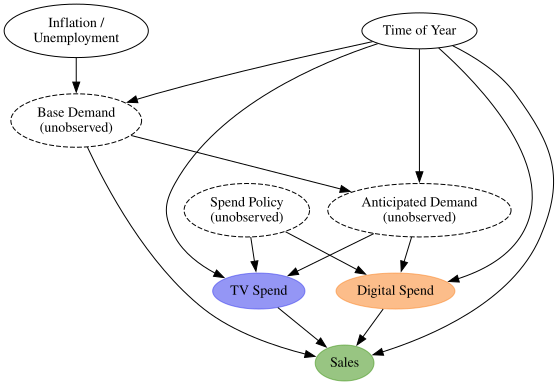

In [26]:
g = gr.Digraph()
g.attr(rankdir="TB")
g.node("C", "Time of Year")
g.node("M", "Inflation /\nUnemployment")
g.node("D", "Base Demand\n(unobserved)", style="dashed")
g.node("A", "Anticipated Demand\n(unobserved)", style="dashed")
g.node("U", "Spend Policy\n(unobserved)", style="dashed")
g.node("TV", "TV Spend", color="#2a2eec80", style="filled")
g.node("DIG", "Digital Spend", color="#fa7c1780", style="filled")
g.node("Y", "Sales", color="#328c0680", style="filled")
edges = [
    ("C", "D"),
    ("M", "D"),
    ("C", "A"),
    ("D", "A"),
    ("A", "TV"),
    ("A", "DIG"),
    ("U", "TV"),
    ("U", "DIG"),
    ("C", "TV"),
    ("C", "DIG"),
    ("D", "Y"),
    ("C", "Y"),
    ("TV", "Y"),
    ("DIG", "Y"),
]
for a, b in edges:
    g.edge(a, b)
g

The path $\text{TV} \leftarrow \text{Anticipated Demand} \leftarrow \text{Base Demand} \rightarrow \text{Sales}$ runs entirely through unobserved variables, so no set of observed controls closes it. The calendar and macro controls capture the *predictable* part of demand, but not the persistent shock that the planners anticipate.

The market comes from {func}`~pymc_marketing.mmm.synthetic_data.simulate_endogenous_spend_market` with `scenario="forecast"`. Base demand is

$$
d_t = 3\,c_t + 2\,\text{inflation}_t - 2\,\text{unemployment}_t + u_t, \qquad u_t = 0.8\,u_{t-1} + \sqrt{1 - 0.8^2}\,\epsilon_t,
$$

where $c_t$ is an annual calendar wave and $u_t$ the unrecorded shock. The planners' forecast is $a_t = 0.7\,d_t + 0.5\,c_t + \text{noise}$, and budgets follow it:

$$
\text{TV}_t = 5 + 0.5\,a_t + 0.6\,p_t + 0.15\,c_t + \text{noise}_t, \qquad \text{Digital}_t = 3 + 0.1\,a_t + 0.42\,p_t + 0.1\,c_t + \text{noise}_t,
$$

with $p_t$ the shared policy shock. Sales are $50 + g_{TV} + g_D + 2.5\,d_t + 1.5\,c_t + \varepsilon_t$, with geometric adstock and Michaelis-Menten saturation for each channel.

After two years of history, the team runs a four-week TV test that cuts spend by 1.5 units per week relative to the business-as-usual plan, and we keep observing the market for twelve more weeks. All spend and sales figures are in £10k per week.

In [27]:
market = simulate_endogenous_spend_market("forecast", random_seed=rng)
df = market.data
n_history = market.n_history
test_start, test_end = market.design[["start_date", "end_date"]].iloc[0]
df.head()

,date,tv,digital,inflation,unemployment,y
0,2022-01-03,1.855298,2.127072,-1.672966,0.016807,49.194378
1,2022-01-10,2.777561,2.361238,-1.189932,0.032612,58.204877
2,2022-01-17,2.906396,2.595617,-1.552148,-0.410442,57.747072
3,2022-01-24,3.339565,2.365600,-1.932323,0.139774,59.613965
4,2022-01-31,2.488210,2.650409,-1.892104,0.477363,53.283940


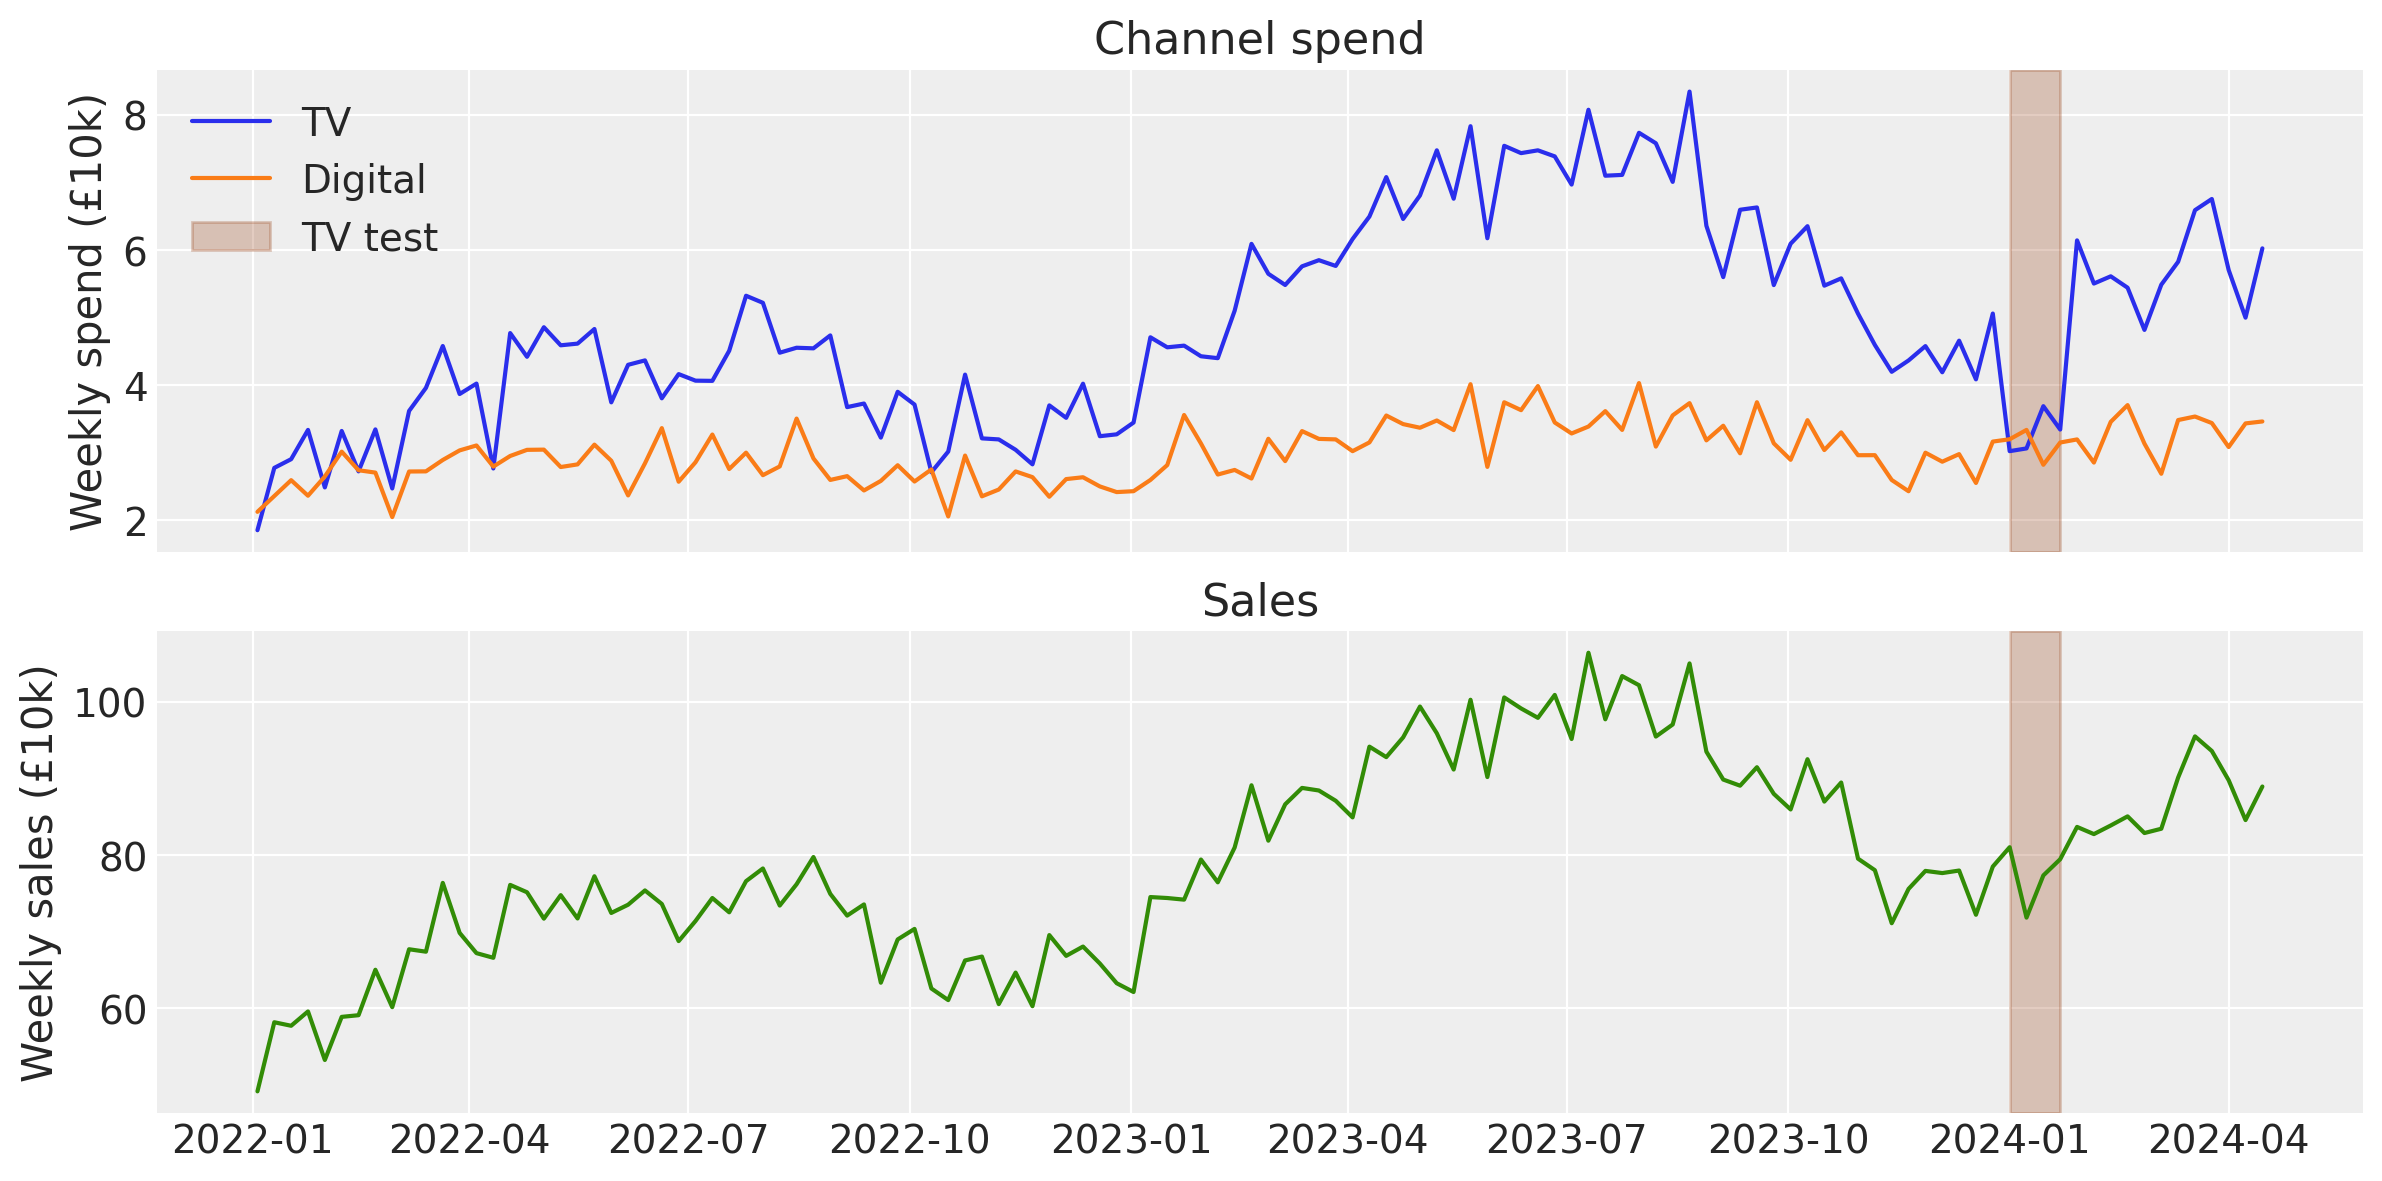

In [28]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
axes[0].plot(df["date"], df["tv"], label="TV")
axes[0].plot(df["date"], df["digital"], label="Digital")
axes[0].set(ylabel="Weekly spend (£10k)", title="Channel spend")
axes[1].plot(df["date"], df["y"], color="C2")
axes[1].set(ylabel="Weekly sales (£10k)", title="Sales")
for ax in axes:
    ax.axvspan(test_start, test_end, color="C4", alpha=0.25, label="TV test")
axes[0].legend(loc="upper left")
plt.tight_layout();

TV and Digital move together because both follow the same forecast and policy shock. That co-movement is not the problem we focus on here; the problem is that the forecast also predicts sales directly.

The simulation lets us compute the quantity an analyst cares about: TV's **marginal return** at its typical operating point (average business-as-usual spend over the history), the extra sales from one more unit of TV spend.

In [29]:
operating_point = market.operating_point
true_marginal_return = market.true_marginal_return
print(
    f"Operating point: {operating_point:.2f}, true TV marginal return: {true_marginal_return:.2f}"
)

Operating point: 4.89, true TV marginal return: 1.94


## Three Ways to Use the Same Experiment

All three models share the same outcome specification: geometric adstock with Michaelis-Menten saturation for each channel, the two standardised macro controls, and annual Fourier seasonality. They differ only in how the experiment enters.

In [30]:
channels = ["tv", "digital"]
controls = ["inflation", "unemployment"]


def make_mmm() -> MMM:
    return MMM(
        date_column="date",
        channel_columns=channels,
        control_columns=controls,
        target_column="y",
        yearly_seasonality=4,
        adstock=GeometricAdstock(l_max=8),
        saturation=MichaelisMentenSaturation(),
    )


def tv_marginal_return(mmm: MMM, x: float = operating_point) -> np.ndarray:
    posterior = mmm.idata.posterior
    lam = posterior["saturation_lam"].sel(channel="tv") * float(
        mmm.scalers["_channel"].sel(channel="tv")
    )
    beta = posterior["saturation_alpha"].sel(channel="tv") * float(
        mmm.scalers["_target"]
    )
    return (beta * lam / (lam + x) ** 2).to_numpy().ravel()

### 1. Plain MMM with the test weeks as data

The simplest option is to give the MMM the whole series, test weeks included, and hope the designed variation speaks for itself.

In [31]:
X, y = df.drop(columns="y"), df["y"]

mmm_plain = make_mmm()
mmm_plain.fit(X, y, random_seed=rng, **sample_kwargs)
mr_plain = tv_marginal_return(mmm_plain)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

### 2. Plain MMM with a lift-test likelihood

The usual calibration workflow summarises the experiment as a lift and adds it to the model with {meth}`~pymc_marketing.mmm.MMM.add_lift_test_measurements`. In practice the lift would come from a quasi-experimental analysis such as an interrupted time series in [CausalPy](https://causalpy.readthedocs.io/). The simulator reports the true lift plus measurement noise with a standard deviation of 1.0, roughly the precision of a four-week national test.

Because the lift already summarises the test weeks, we fit this model on the pre-test history only, so the experiment is not counted twice.

In [32]:
market.lift_test

,channel,x,delta_x,delta_y,sigma
0,tv,4.781583,-1.5,-3.069448,1.0


In [33]:
X_hist, y_hist = X.iloc[:n_history], y.iloc[:n_history]

mmm_lift = make_mmm()
mmm_lift.build_model(X_hist, y_hist)
mmm_lift.add_lift_test_measurements(market.lift_test)
mmm_lift.fit(X_hist, y_hist, random_seed=rng, **sample_kwargs)
mr_lift = tv_marginal_return(mmm_lift)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

### 3. Budget model with the lift-test design

{class}`~pymc_marketing.mmm.budget_model.BudgetModelEffect` adds a spend equation for each channel. Budgets respond to the observed demand drivers (here the MMM's controls and an annual Fourier basis), and whatever those drivers do not explain is the channel's *budget surprise*:

$$
\text{spend}_{c,t} = \underbrace{a_c + \psi_c^\top \text{controls}_t + \phi_c^\top \text{Fourier}_t}_{m_{c,t}} + v_{c,t},
\qquad v_{c,t} \sim \mathcal{N}(0, s_c^2).
$$

The surprise mixes allocation noise, which is unrelated to demand, with the unrecorded forecast, which is not. If the surprises and the sales error are jointly Gaussian, the sales error splits into a part explained by the surprises and a remainder independent of them, so the sales mean gains a control-function term:

$$
\mu_t = \text{MMM}_t + \sum_c \gamma_c\, v_{c,t}.
$$

The control function removes the confounding but uses up variation: once $v_{c,t}$ enters the sales equation, what is left in spend is $m_{c,t}$, built from the same drivers that enter sales directly. The lift test supplies the missing variation. Its spend change is set by design, independently of demand, so the effect subtracts it *before* computing the surprise. The designed change is never mistaken for a budget choice, and the test weeks enter the sales likelihood as ordinary data with no lift likelihood.

The design is described with one row per experiment. `mode="shift"` means spend moved by a known `delta_x` relative to what would otherwise have been chosen. Use `mode="set"` for designs that fix spend outright, such as a holdout at zero, where spend in those cells carries no demand information and is masked out of the budget model.

In [34]:
design = market.design
shift, holdout = lift_test_design(design, dates=df["date"], channels=channels)
design

,channel,start_date,end_date,mode,delta_x
0,tv,2024-01-01,2024-01-22,shift,-1.5


In [35]:
budget = BudgetModelEffect(design=design)

mmm_budget = make_mmm()
mmm_budget.add_mu_effect(budget)
mmm_budget.fit(X, y, random_seed=rng, **sample_kwargs)
mr_budget = tv_marginal_return(mmm_budget)

NUTS[nutpie]: [budget_gamma, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

In [36]:
for name, m in [
    ("plain", mmm_plain),
    ("lift likelihood", mmm_lift),
    ("budget model", mmm_budget),
]:
    n_div = int(m.idata.sample_stats["diverging"].sum())
    print(f"{name:>16}: {n_div} divergences")

           plain: 3 divergences
 lift likelihood: 1 divergences
    budget model: 0 divergences


All three fits sample cleanly, with at most a handful of divergent transitions out of 4,000 draws.

## Comparing the Marginal Return of TV

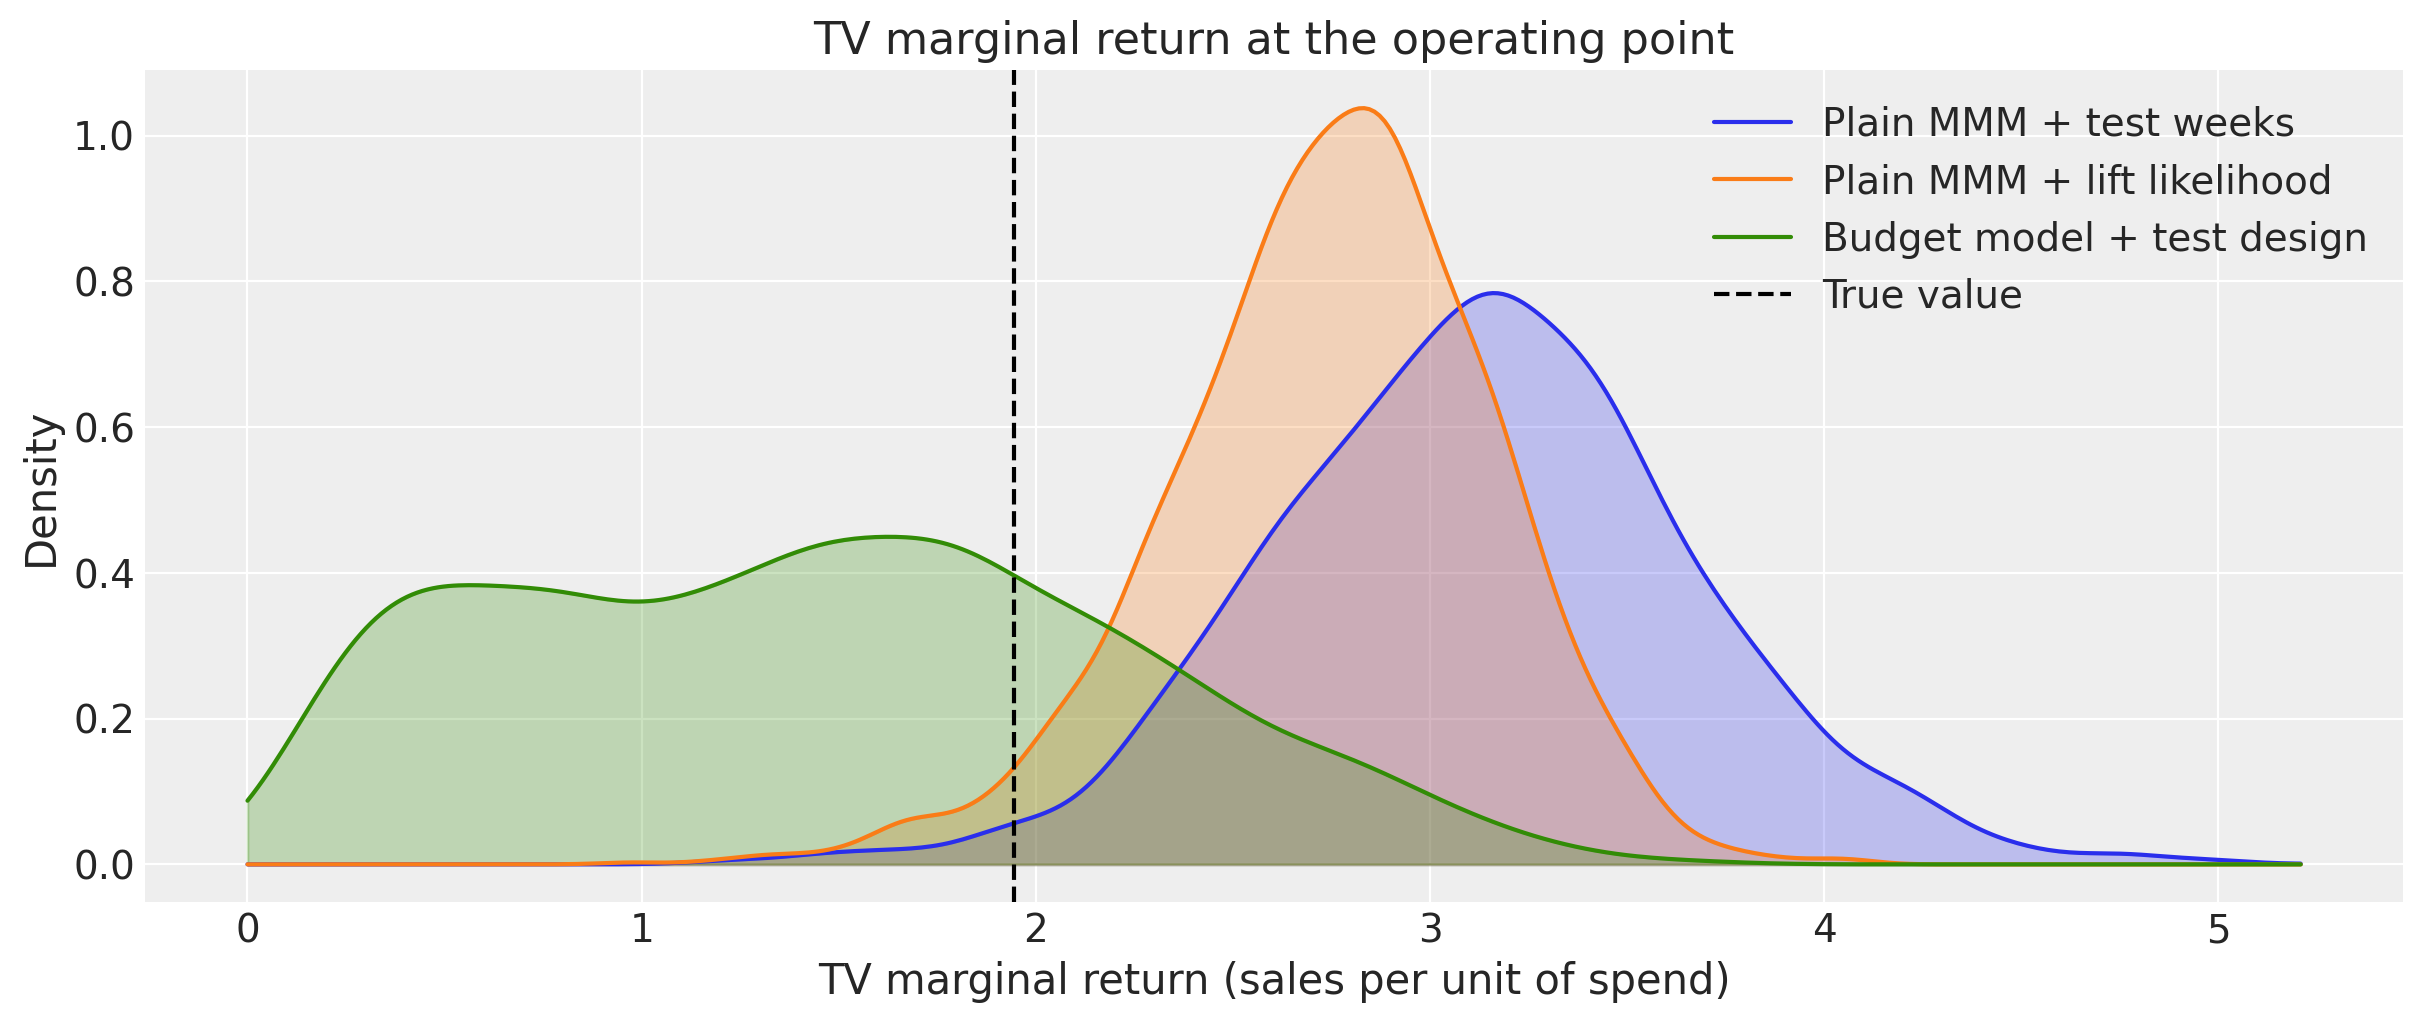

In [37]:
fits = [
    (mr_plain, "Plain MMM + test weeks", "C0"),
    (mr_lift, "Plain MMM + lift likelihood", "C1"),
    (mr_budget, "Budget model + test design", "C2"),
]
grid = np.linspace(0, max(np.quantile(v, 0.999) for v, *_ in fits) * 1.05, 400)

fig, ax = plt.subplots(figsize=(12, 5))
for values, label, color in fits:
    density = gaussian_kde(values)(grid)
    ax.fill_between(grid, density, color=color, alpha=0.25)
    ax.plot(grid, density, color=color, label=label)
ax.axvline(true_marginal_return, color="black", linestyle="--", label="True value")
ax.set(
    xlabel="TV marginal return (sales per unit of spend)",
    ylabel="Density",
    title="TV marginal return at the operating point",
)
ax.legend();

In [38]:
pd.DataFrame(
    {
        label: {
            "mean": values.mean(),
            "3%": np.quantile(values, 0.03),
            "97%": np.quantile(values, 0.97),
        }
        for values, label, _ in fits
    }
).T.assign(true=true_marginal_return).round(2)

,mean,3%,97%,true
Plain MMM + test weeks,3.13,2.15,4.16,1.94
Plain MMM + lift likelihood,2.75,1.92,3.44,1.94
Budget model + test design,1.44,0.20,2.92,1.94


The plain MMM credits TV with the demand its budget followed: its whole interval sits above the true value, and the four test weeks barely move it, because they are diluted among a hundred weeks in which spend chased demand. The lift likelihood pulls the estimate down to 2.75, and its interval only just reaches the truth. The budget model moves furthest, past the truth to 1.44, with the widest interval: it covers the true value, and it is honest about how little one short test pins down.

One simulated market is one draw. Whether a method helps is a question about its behaviour across markets, so we repeat the whole exercise.

## Replicating Across Markets

We simulate six further markets from the same data-generating process with different seeds and fit all three models to each, with a lighter sampling budget. For every market we record the error of the posterior mean of TV's marginal return, whether the 94% interval covers the truth, and the number of divergent transitions.

In [39]:
replication_kwargs = {**sample_kwargs, "draws": 500, "tune": 1_000, "chains": 2}


def fit_all(seed: int) -> list[dict]:
    market_k = simulate_endogenous_spend_market("forecast", random_seed=seed)
    market_rng = np.random.default_rng(seed)
    data, n_hist = market_k.data, market_k.n_history
    x_op, truth = market_k.operating_point, market_k.true_marginal_return
    X_m, y_m = data.drop(columns="y"), data["y"]
    rows = []

    def record(label, model, gamma=np.nan):
        values = tv_marginal_return(model, x=x_op)
        lower, upper = np.quantile(values, [0.03, 0.97])
        rows.append(
            {
                "market": seed,
                "fit": label,
                "error": values.mean() - truth,
                "lower_error": lower - truth,
                "upper_error": upper - truth,
                "covers_truth": lower <= truth <= upper,
                "divergences": int(model.idata.sample_stats["diverging"].sum()),
                "gamma_tv_prob_positive": gamma,
            }
        )

    plain = make_mmm()
    plain.fit(X_m, y_m, random_seed=market_rng, **replication_kwargs)
    record("Plain MMM + test weeks", plain)

    calibrated = make_mmm()
    calibrated.build_model(X_m.iloc[:n_hist], y_m.iloc[:n_hist])
    calibrated.add_lift_test_measurements(market_k.lift_test)
    calibrated.fit(
        X_m.iloc[:n_hist],
        y_m.iloc[:n_hist],
        random_seed=market_rng,
        **replication_kwargs,
    )
    record("Plain MMM + lift likelihood", calibrated)

    effect = BudgetModelEffect(design=market_k.design)
    joint = make_mmm()
    joint.add_mu_effect(effect)
    joint.fit(X_m, y_m, random_seed=market_rng, **replication_kwargs)
    gamma_tv = joint.idata.posterior["budget_gamma"].sel(budget_channel="tv")
    record("Budget model + test design", joint, float((gamma_tv > 0).mean()))
    return rows


replication = pd.DataFrame(
    [row for seed_k in range(101, 107) for row in fit_all(seed_k)]
)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [budget_gamma, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


...

Output()

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, gamma_fourier, gamma_control, intercept_contribution, y_sigma]


Output()

NUTS[nutpie]: [budget_gamma, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

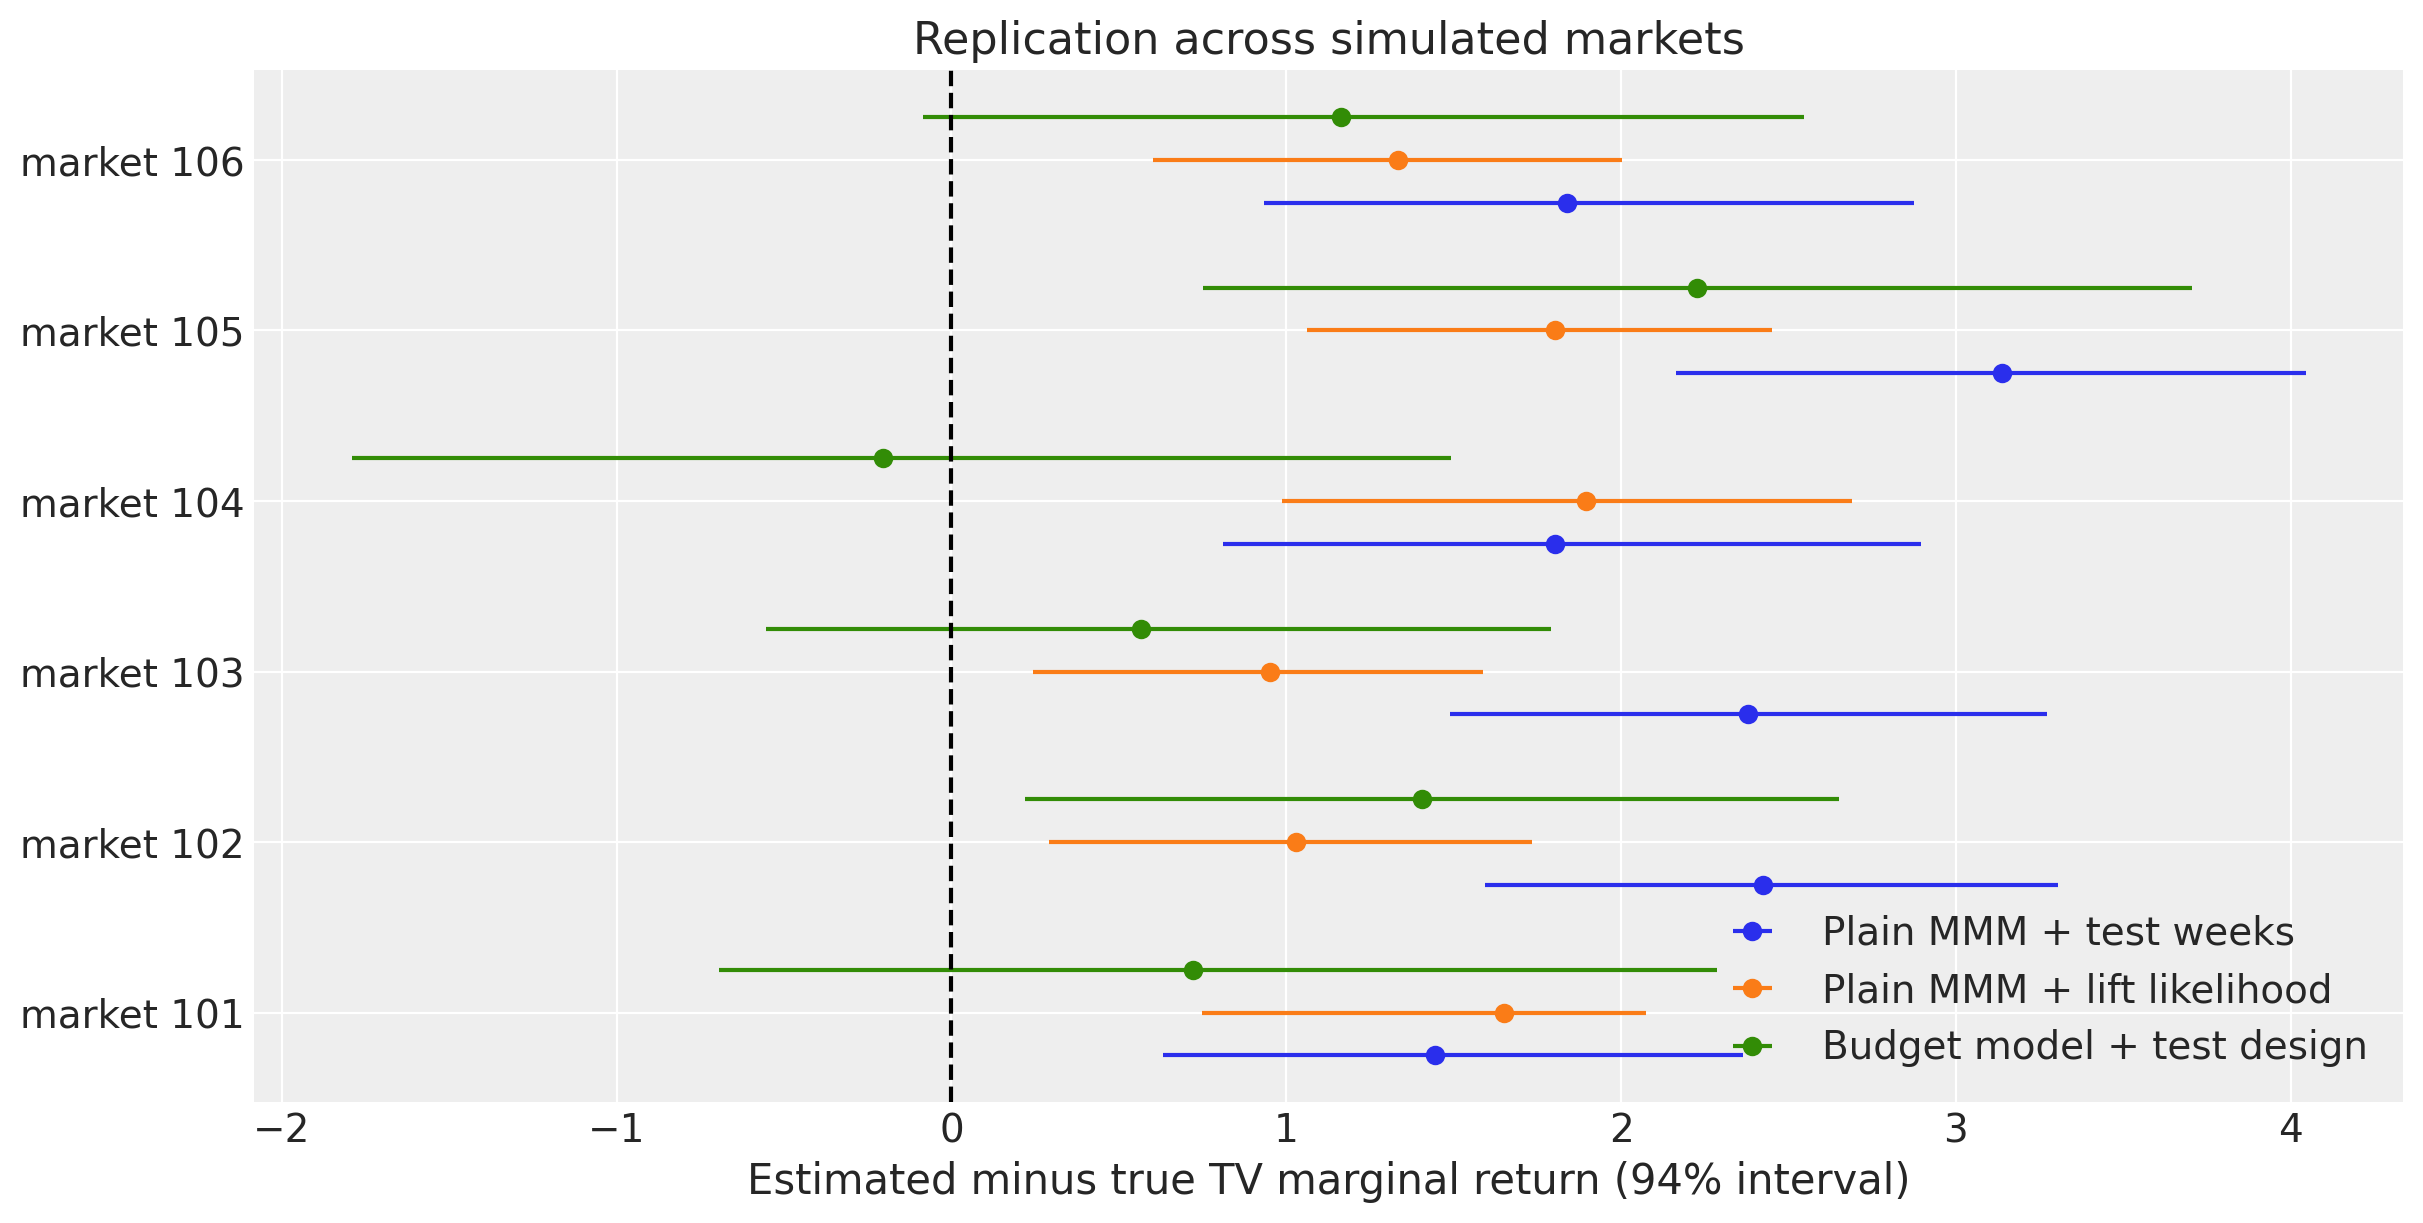

In [40]:
fit_labels = [label for _, label, _ in fits]
fig, ax = plt.subplots(figsize=(12, 6))
for k, (label, color) in enumerate(zip(fit_labels, ["C0", "C1", "C2"], strict=True)):
    sub = replication[replication["fit"] == label].reset_index(drop=True)
    positions = np.arange(len(sub)) + (k - 1) * 0.25
    ax.errorbar(
        sub["error"],
        positions,
        xerr=[sub["error"] - sub["lower_error"], sub["upper_error"] - sub["error"]],
        fmt="o",
        color=color,
        label=label,
    )
ax.axvline(0, color="black", linestyle="--")
ax.set_yticks(
    np.arange(replication["market"].nunique()),
    [f"market {m}" for m in replication["market"].unique()],
)
ax.set(
    xlabel="Estimated minus true TV marginal return (94% interval)",
    title="Replication across simulated markets",
)
ax.legend(loc="lower right");

In [41]:
replication.groupby("fit", sort=False).agg(
    coverage=("covers_truth", "mean"),
    mean_abs_error=("error", lambda e: e.abs().mean()),
    mean_interval_width=(
        "upper_error",
        lambda u: (u - replication.loc[u.index, "lower_error"]).mean(),
    ),
    divergences=("divergences", "sum"),
    mean_prob_gamma_tv_positive=("gamma_tv_prob_positive", "mean"),
).round(2)

,coverage,mean_abs_error,mean_interval_width,divergences,mean_prob_gamma_tv_positive
fit,,,,,
Plain MMM + test weeks,0.00,2.17,1.86,5,NaN
Plain MMM + lift likelihood,0.00,1.44,1.43,130,NaN
Budget model + test design,0.67,1.05,2.77,0,0.94


Across the six markets neither plain fit's interval ever covers the truth; both overstate TV every time. The budget model covers it in four markets out of six and has the smallest average error, 1.05 against 1.44 for the lift likelihood and 2.17 for the plain MMM. It does not remove the bias, though: its estimate sits above the truth in five markets, and in markets 102 and 105 its whole interval does. It also pays for coverage with width, its intervals being about twice as wide as the lift likelihood's. The lift-likelihood fits recorded 130 divergent transitions across the six markets, so their narrow intervals also rest on weaker sampling. Averaged over the markets, the posterior probability that $\gamma_{TV} > 0$ is 0.94: the budget model generally detects that TV budgets chase demand, even where it corrects only part of the bias.

## What the Control Function Absorbs

The control-function term is stored as `budget_effect_contribution`. In the simulation we know the piece of sales driven by the unobserved demand shock, so we can compare the two. They should not match: budgets see only a noisy forecast of the shock, and the control function uses only this week's surprise, while the shock is persistent.

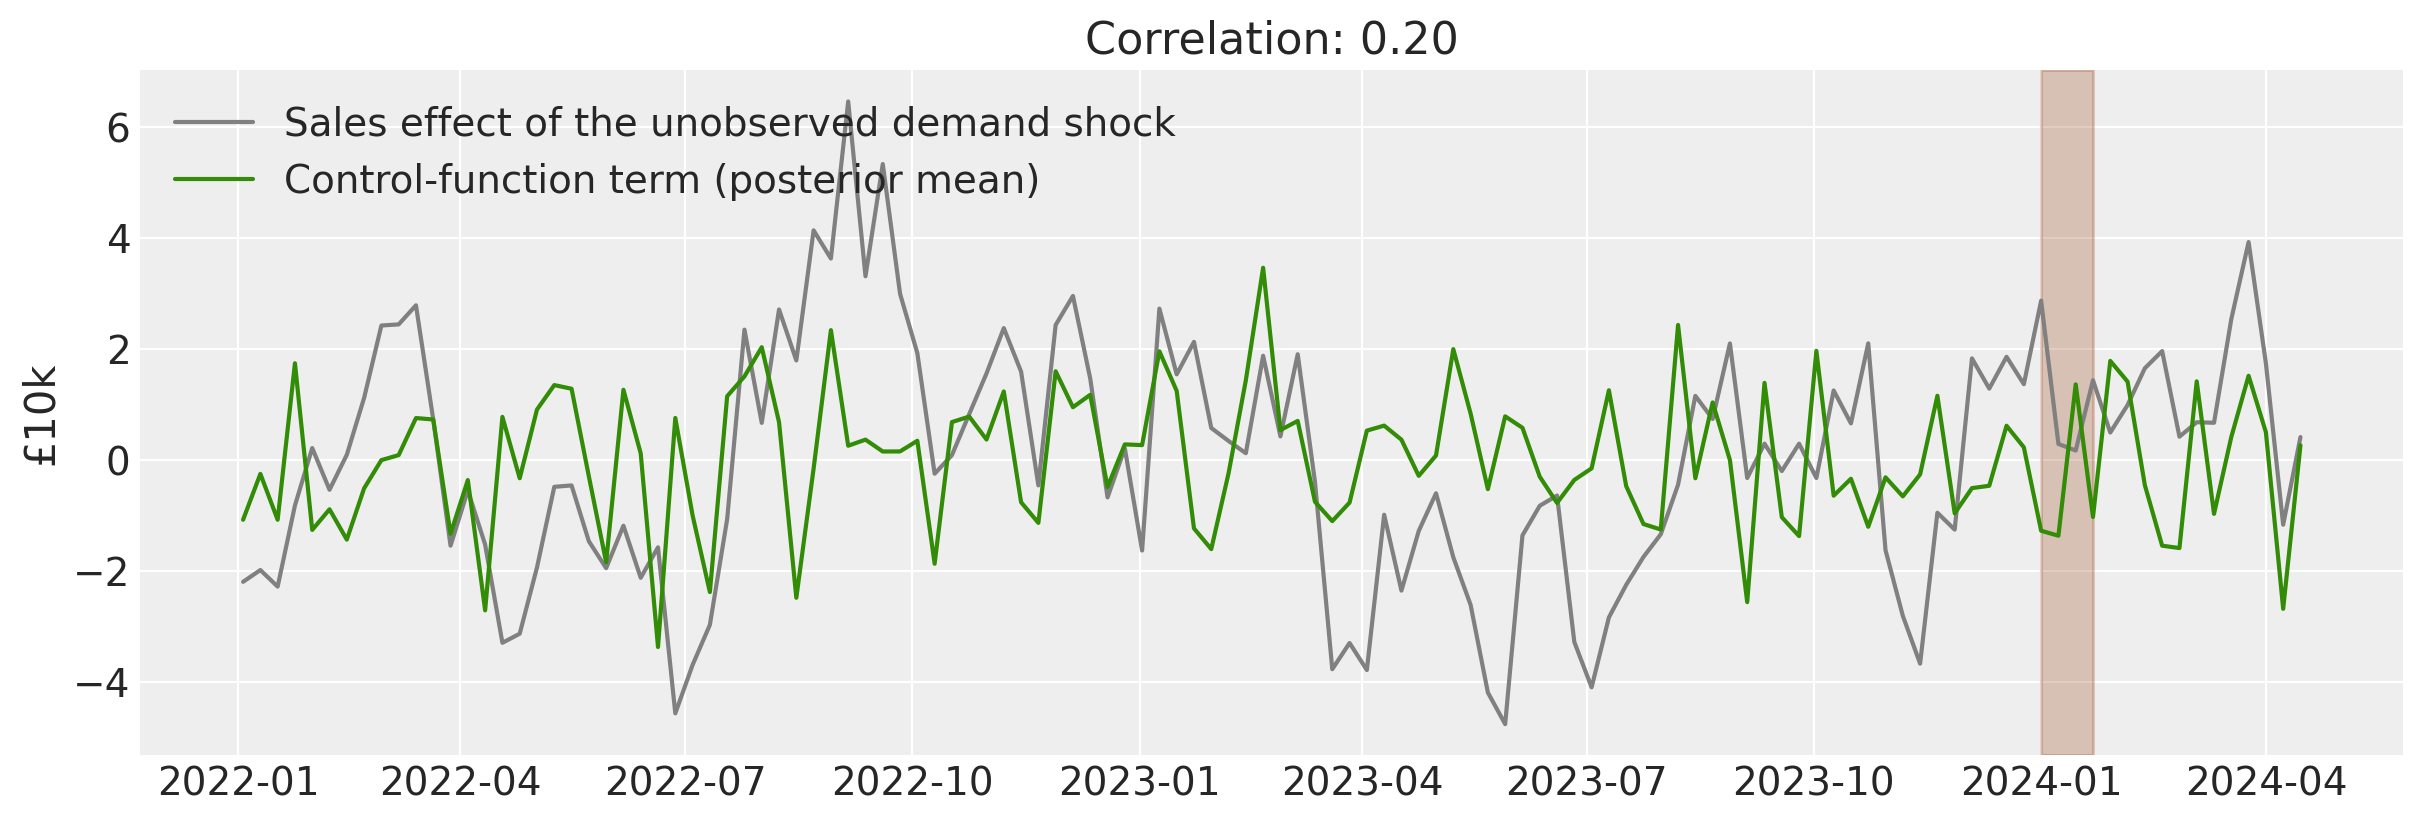

In [42]:
cf = (
    mmm_budget.idata.posterior["budget_effect_contribution"].mean(("chain", "draw"))
    * float(mmm_budget.scalers["_target"])
).to_series()
shock_effect = pd.Series(2.5 * market.demand_shock, index=cf.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    cf.index,
    shock_effect - shock_effect.mean(),
    color="gray",
    label="Sales effect of the unobserved demand shock",
)
ax.plot(cf.index, cf, color="C2", label="Control-function term (posterior mean)")
ax.axvspan(test_start, test_end, color="C4", alpha=0.25)
ax.set(ylabel="£10k", title=f"Correlation: {np.corrcoef(cf, shock_effect)[0, 1]:.2f}")
ax.legend(loc="upper left");

In this market the term tracks the shock only loosely (a correlation of 0.20). It picks up the week-to-week movements that reach TV budgets, not the slow swings of the persistent shock. That is the contemporaneous-surprise premise listed under the assumptions below, and it is one reason the correction is only partial in some markets.

## The Control Function as an Exogeneity Check

If spend were exogenous, the budget surprises would carry no demand information and every $\gamma_c$ would be zero. The posterior for $\gamma_c$ therefore measures how much weight the plain MMM's exogeneity assumption was carrying. This is a Bayesian analogue of the classical control-function (Durbin-Wu-Hausman) test for endogeneity [(Rivers & Vuong, 1988](https://doi.org/10.1016/0304-4076(88)90063-2); [Wooldridge, 2015)](https://doi.org/10.3368/jhr.50.2.420).

{meth}`~pymc_marketing.mmm.budget_model.BudgetModelEffect.exogeneity_summary` reports it per channel. The interval columns are in scaled units; `gamma_per_spend_unit` converts to sales per unexplained unit of spend. `contraction` compares posterior and prior spread, and `identified_by_design` records whether a lift-test design supplied excluded variation for that coefficient.

In [43]:
budget.exogeneity_summary(mmm_budget).round(3)

,channel,gamma_mean,gamma_lower,gamma_upper,gamma_per_spend_unit,prob_positive,prior_sd,posterior_sd,contraction,identified_by_design,note
0,tv,0.201,0.081,0.310,2.563,0.999,0.5,0.061,0.878,True,
1,digital,-0.128,-0.474,0.056,-3.377,0.198,0.5,0.148,0.704,False,identified by functional form only (no lift-te...


In this market TV's coefficient is clearly positive: its interval excludes zero, and the posterior probability that it is positive is 0.999. Unexplained TV budget moves carried demand, so the plain MMM's exogeneity assumption was doing real work. Digital's coefficient has no designed variation: it is identified only through the nonlinearity of the response curve, so the summary flags it. Its interval includes zero but leans negative (probability of about 0.80 below zero), the opposite sign to Digital's small true dependence on the forecast. Without a design the check still runs, but its verdict leans on functional-form assumptions and the priors, and it should be read as a sensitivity analysis rather than a test.

### When spend follows only recorded drivers

The same component can be added to a model where you believe spend is exogenous, as a check on that belief. We simulate a market whose budgets respond strongly to seasonality and the macro controls, all of which the MMM includes, but not to the unrecorded shock (`scenario="observed_only"`), and fit the budget model without any design.

In [44]:
market_exog = simulate_endogenous_spend_market("observed_only", random_seed=rng)
X_exog, y_exog = market_exog.data.drop(columns="y"), market_exog.data["y"]

budget_exog = BudgetModelEffect()
mmm_exog = make_mmm()
mmm_exog.add_mu_effect(budget_exog)
mmm_exog.fit(X_exog, y_exog, random_seed=rng, **sample_kwargs)

budget_exog.exogeneity_summary(mmm_exog).round(3)

NUTS[nutpie]: [budget_gamma, budget_spend_fourier_coef, budget_spend_control_coef, budget_spend_intercept, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_alpha, intercept_contribution, y_sigma, budget_spend_sigma]


Output()

,channel,gamma_mean,gamma_lower,gamma_upper,gamma_per_spend_unit,prob_positive,prior_sd,posterior_sd,contraction,identified_by_design,note
0,tv,-0.125,-0.468,0.092,-1.872,0.242,0.5,0.158,0.683,False,identified by functional form only (no lift-te...
1,digital,-0.127,-0.453,0.072,-3.052,0.224,0.5,0.149,0.703,False,identified by functional form only (no lift-te...


Both intervals include zero, so there is no false alarm, but both coefficients lean negative (probabilities of about 0.76 and 0.78 below zero). Without designed variation, a negative $\gamma$ can trade off against a steeper response curve, and the priors decide where the posterior settles. A leaning $\gamma$ for an untested channel is therefore not evidence of endogeneity; {ref}`mmm_endogenous_budget_scenarios` shows the same pattern in its negative control.

## Predictions and Counterfactuals

The control-function term represents demand that actually happened. Changing spend in a scenario is an intervention, and interventions are never budget surprises. The effect therefore computes surprises from a stored copy of the chosen spend rather than from the channel data:

- counterfactuals from {class}`~pymc_marketing.mmm.incrementality.Incrementality` and the budget optimizer change the media response but hold the control-function term at its factual value;
- on future dates the surprise is zero, its expectation for spend that has not been chosen yet. Forecast intervals therefore omit the variance the control function absorbed in-sample and are somewhat too narrow.

In [45]:
future = pd.DataFrame(
    {
        "date": pd.date_range(
            df["date"].max() + pd.Timedelta(weeks=1), periods=8, freq="W-MON"
        ),
        "tv": operating_point,
        "digital": df["digital"].mean(),
        "inflation": 0.0,
        "unemployment": 0.0,
    }
)
forecast = mmm_budget.sample_posterior_predictive(
    future,
    extend_idata=False,
    var_names=["y", "budget_effect_contribution"],
    random_seed=rng,
)
max_cf = float(abs(forecast["budget_effect_contribution"]).max())
print(f"Largest absolute control-function term over the forecast: {max_cf:.1f}")

Sampling: [y]


Output()

Largest absolute control-function term over the forecast: 0.0


## Assumptions and Limitations

The budget model buys recovery with new premises, and none of them can be checked from sales data alone:

- **The observed drivers capture the predictable part of budget setting.** If planners respond to something recorded, such as a demand forecast, pass it through `drivers` so it enters the spend equation. A driver acts as an instrument, so it must be unrelated to the sales error: never pass recorded outcomes such as lagged sales.
- **The budget surprise relates to demand linearly.** The control function is linear in the surprise.
- **This period's surprise carries the demand information relevant to this period's sales.** Persistent demand shocks, as in this market, strain that assumption because last period's surprise also carries this period's demand. The designed test weeks help cover the gap.
- **Designs are known.** A `"shift"` design must be a known change relative to what would otherwise have been chosen. A test that sets spend outright should use `mode="set"`.
- **Do not count the same experiment twice.** If the test periods are in the MMM data as part of a design, do not also add their lift summary with {meth}`~pymc_marketing.mmm.MMM.add_lift_test_measurements`; the method warns when the channels overlap. The lift likelihood remains the right tool for experiments whose periods or units are not in the MMM data, such as user-level holdouts.

What a single experiment buys is local. It pins down TV's response near the tested spend. The full response curve, and Digital's causal effect, still rest on the saturation curve, the priors, and the budget model's premises. Tests at different spend levels, and on other channels, remain the anchor. For budgets that chase targets, spend that follows search demand, and a negative control, see {ref}`mmm_endogenous_budget_scenarios`.

## References

- Manchanda, P., Rossi, P. E., & Chintagunta, P. K. (2004). Response modeling with nonrandom marketing-mix variables. *Journal of Marketing Research*, 41(4), 467-478.
- Petrin, A., & Train, K. (2010). A control function approach to endogeneity in consumer choice models. *Journal of Marketing Research*, 47(1), 3-13.
- Rivers, D., & Vuong, Q. H. (1988). Limited information estimators and exogeneity tests for simultaneous probit models. *Journal of Econometrics*, 39(3), 347-366.
- Wooldridge, J. M. (2015). Control function methods in applied econometrics. *Journal of Human Resources*, 50(2), 420-445.

In [46]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 29 Sep 2026

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_marketing: 1.0.0.dev0
scipy         : 1.18.0

Watermark: 2.6.0

